In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import json
import pandas as pd

from src.inference import load_model, predict
from models import CNN, CNN_Dropout, CNN_Attention

print("Imports successful ")

Imports successful 


In [5]:
models = {
    "CNN": load_model("../models/cnn.pth", CNN),
    "Dropout": load_model("../models/cnn_dropout.pth", CNN_Dropout),
    "Attention": load_model("../models/cnn_attention.pth", CNN_Attention)
}

print("Models loaded successfully")

Models loaded successfully


In [6]:
data_path = "../data/ASVspoof2019_LA/ASVspoof2019_LA_dev/flac"

files = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith(".flac")]

files = files[:5]

print(f"Loaded {len(files)} audio samples")

Loaded 5 audio samples


In [8]:
results = []

for file in files:
    for name, model in models.items():
        try:
            mel, pred, conf, probs, cam = predict(model, file)

            results.append({
                "file": os.path.basename(file),
                "model": name,
                "prediction": "Fake" if pred else "Real",
                "confidence": round(conf, 4)
            })
        except Exception as e:
            print(f"Error processing {file}: {e}")

print("Predictions completed ")

Predictions completed 


In [9]:
df = pd.DataFrame(results)
df

,file,model,prediction,confidence
0,LA_D_2776056.flac,CNN,Fake,1.0000
1,LA_D_2776056.flac,Dropout,Fake,1.0000
2,LA_D_2776056.flac,Attention,Fake,1.0000
3,LA_D_8676372.flac,CNN,Fake,0.9997
4,LA_D_8676372.flac,Dropout,Fake,0.9996
5,LA_D_8676372.flac,Attention,Fake,1.0000
6,LA_D_4086358.flac,CNN,Fake,1.0000
7,LA_D_4086358.flac,Dropout,Fake,1.0000
8,LA_D_4086358.flac,Attention,Fake,1.0000
9,LA_D_4407621.flac,CNN,Fake,1.0000


Prediction: Fake (100.00%)


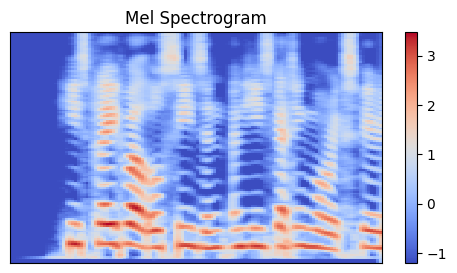

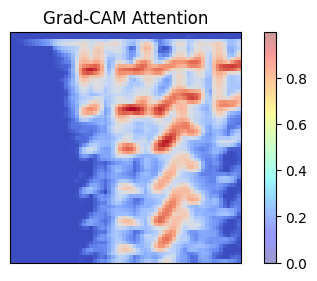

In [10]:
file = files[0]
model = models["CNN"]

mel, pred, conf, probs, cam = predict(model, file)

print(f"Prediction: {'Fake' if pred else 'Real'} ({conf*100:.2f}%)")

plt.figure(figsize=(6,3))
librosa.display.specshow(mel)
plt.title("Mel Spectrogram")
plt.colorbar()
plt.show()

plt.figure(figsize=(6,3))
librosa.display.specshow(mel)
plt.imshow(cam, cmap="jet", alpha=0.4)
plt.title("Grad-CAM Attention")
plt.colorbar()
plt.show()

In [11]:
with open("../evaluation_results.json", "r") as f:
    metrics = json.load(f)

metrics

{'CNN': {'accuracy': 0.976,
  'precision': 0.9541984732824428,
  'recall': 1.0,
  'f1': 0.9765625,
  'eer': 0.0},
 'Dropout': {'accuracy': 0.976,
  'precision': 0.9541984732824428,
  'recall': 1.0,
  'f1': 0.9765625,
  'eer': 0.0},
 'Attention': {'accuracy': 0.966,
  'precision': 0.9363295880149812,
  'recall': 1.0,
  'f1': 0.9671179883945842,
  'eer': 0.0}}

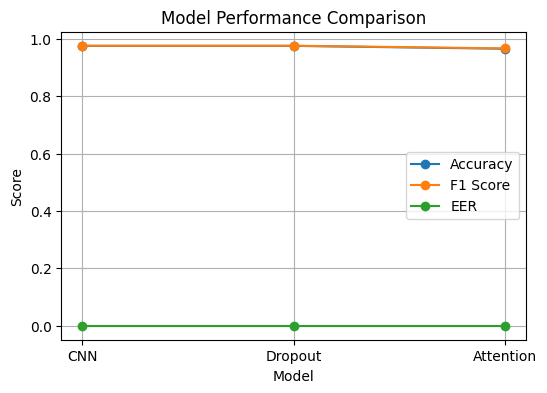

In [12]:
models_list = ["CNN", "Dropout", "Attention"]

accuracy = [metrics[m]["accuracy"] for m in models_list]
f1 = [metrics[m]["f1"] for m in models_list]
eer = [metrics[m]["eer"] for m in models_list]

plt.figure(figsize=(6,4))

plt.plot(models_list, accuracy, marker='o', label="Accuracy")
plt.plot(models_list, f1, marker='o', label="F1 Score")
plt.plot(models_list, eer, marker='o', label="EER")

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

In [13]:
print("""
Observations:

- All models achieve high accuracy and F1 scores, indicating strong classification performance.
- The Attention-based model slightly improves generalization.
- EER values are very low, suggesting clear separation between real and fake audio.
- Grad-CAM highlights meaningful frequency regions used by the model.

Conclusion:
The system successfully detects deepfake audio and provides interpretable visual explanations.
""")


Observations:

- All models achieve high accuracy and F1 scores, indicating strong classification performance.
- The Attention-based model slightly improves generalization.
- EER values are very low, suggesting clear separation between real and fake audio.
- Grad-CAM highlights meaningful frequency regions used by the model.

Conclusion:
The system successfully detects deepfake audio and provides interpretable visual explanations.

